### Caffeine Consumption Code

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import re
from io import StringIO

In [3]:
# load the student survvey data
students = pd.read_csv("/Users/sarakoshy/Downloads/Student Insomnia and Educational Outcomes Dataset.csv")
# look at the first few rows to make sure it loaded correctly
students.head()

,Timestamp,1. What is your year of study?,2. What is your gender?,3. How often do you have difficulty falling asleep at night?,"4. On average, how many hours of sleep do you get on a typical day?",5. How often do you wake up during the night and have trouble falling back asleep?,6. How would you rate the overall quality of your sleep?,7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?,"8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?","9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?",10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?,"11. How often do you use electronic devices (e.g., phone, computer) before going to sleep?","12. How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?",13. How often do you engage in physical activity or exercise?,14. How would you describe your stress levels related to academic workload?,15. How would you rate your overall academic performance (GPA or grades) in the past semester?
0,10/24/2024 16:51:15,Graduate student,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Sometimes,Often,Often (3-4 times a week),Moderate impact,Often (5-6 times a week),Rarely (1-2 times a week),Sometimes (3-4 times a week),High stress,Average
1,10/24/2024 16:51:51,Third year,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Often,Sometimes,Sometimes (1-2 times a week),Major impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Sometimes (3-4 times a week),Low stress,Good
2,10/24/2024 16:52:21,First year,Female,Sometimes (3-4 times a week),7-8 hours,Sometimes (3-4 times a week),Good,Often,Often,Sometimes (1-2 times a week),Major impact,Often (5-6 times a week),Often (5-6 times a week),Often (5-6 times a week),High stress,Below Average
3,10/24/2024 16:53:00,Third year,Male,Often (5-6 times a week),More than 8 hours,Sometimes (3-4 times a week),Poor,Often,Often,Rarely (1-2 times a month),Minor impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Every day,Extremely high stress,Excellent
4,10/24/2024 16:53:25,Graduate student,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Very good,Always,Sometimes,Sometimes (1-2 times a week),Moderate impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Often (5-6 times a week),Low stress,Average


In [21]:
# add a browser header so the website accepts the request more reliably
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Wikipedia page we are scraping caffeine data from
url = "https://en.wikipedia.org/wiki/Caffeine"

# request the page and store the HTML content
response = requests.get(url, headers=headers)

# stop if the page was not retrieved successfully
response.raise_for_status()

# read all tables from the page HTML
tables = pd.read_html(StringIO(response.text))

# check how many tables were found so we can pick the correct one
print(len(tables))

32


In [5]:
# grab the table we want from the list of scraped tables
web_caffeine = tables[3]
# check the first few rows
web_caffeine.head()

,Product,Serving size,Caffeine per serving (mg),Caffeine (mg/L)
0,Caffeine tablet (regular-strength),1 tablet,100,—
1,Caffeine tablet (extra-strength),1 tablet,200,—
2,Excedrin tablet,1 tablet,65,—
3,Percolated coffee,207 mL (7.0 US fl oz),80–135,386–652
4,Drip coffee,207 mL (7.0 US fl oz),115–175,555–845


In [6]:
# standardize column names first so they are easier to reference later
web_caffeine.columns = web_caffeine.columns.str.strip().str.lower().str.replace(" ", "_")

# convert caffeine entries into usable numeric values
def clean_caffeine(val):
    # keep missing values as missing
    if pd.isna(val):
        return None

    # turn everything into text so it can be cleaned consistently
    val = str(val)

    # remove citation marks from scraped Wikipedia values
    val = re.sub(r"\[\d+\]", "", val).strip()

    # if caffeine is listed as a range, use the midpoint as an estimate
    if "–" in val:
        low, high = val.split("–")
        return (float(low) + float(high)) / 2

    # otherwise, convert the single value to a number
    try:
        return float(val)
    except:
        return None

# make a new numeric column for caffeine amount in mg
web_caffeine["caffeine_mg"] = web_caffeine["caffeine_per_serving_(mg)"].apply(clean_caffeine)

# check the cleaned result
web_caffeine.head()

,product,serving_size,caffeine_per_serving_(mg),caffeine_(mg/l),caffeine_mg
0,Caffeine tablet (regular-strength),1 tablet,100,—,100.0
1,Caffeine tablet (extra-strength),1 tablet,200,—,200.0
2,Excedrin tablet,1 tablet,65,—,65.0
3,Percolated coffee,207 mL (7.0 US fl oz),80–135,386–652,107.5
4,Drip coffee,207 mL (7.0 US fl oz),115–175,555–845,145.0


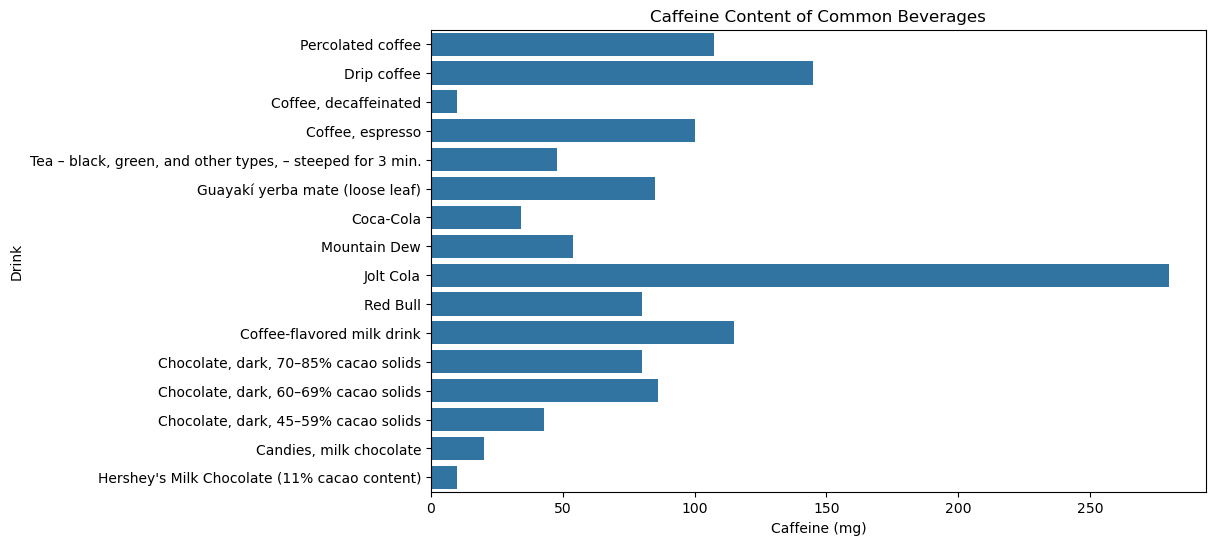

In [20]:
# Graph 1: compare caffeine amounts across common beverages

# keep keywords for common drink types
drink_keywords = ["coffee", "tea", "cola", "bull", "dew", "mate"]

# keep only rows where the product name matches one of those drinks
drink_caffeine = web_caffeine[
    web_caffeine["product"].str.lower().str.contains("|".join(drink_keywords), na=False)
].copy()

# make the plot bigger so the labels fit better
plt.figure(figsize=(10, 6))

# create a bar chart of caffeine amount by drink
sns.barplot(data=drink_caffeine, x="caffeine_mg", y="product")

# add title and axis labels
plt.title("Caffeine Content of Common Beverages")
plt.xlabel("Caffeine (mg)")
plt.ylabel("Drink")

# show the graph
plt.show()

In [8]:
# save the long question names into shorter variable names
caffeine_col = "12. How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?"
stress_col = "14. How would you describe your stress levels related to academic workload?"
sleep_col = "4. On average, how many hours of sleep do you get on a typical day?"

In [19]:
# turn sleep responses into numbers so they are easier to analyze
def clean_sleep(val):
    # keep missing values as missing
    if pd.isna(val):
        return None

    # clean the text by removing "hours"
    val = str(val).lower().replace("hours", "").strip()

    # if sleep is given as a range, use the midpoint
    if "-" in val:
        low, high = val.split("-")
        return (float(low) + float(high)) / 2

    # if it is already one value, convert it to a number
    try:
        return float(val)
    except:
        return None

# apply the function to make a numeric sleep column
students["sleep_mid"] = students[sleep_col].apply(clean_sleep)

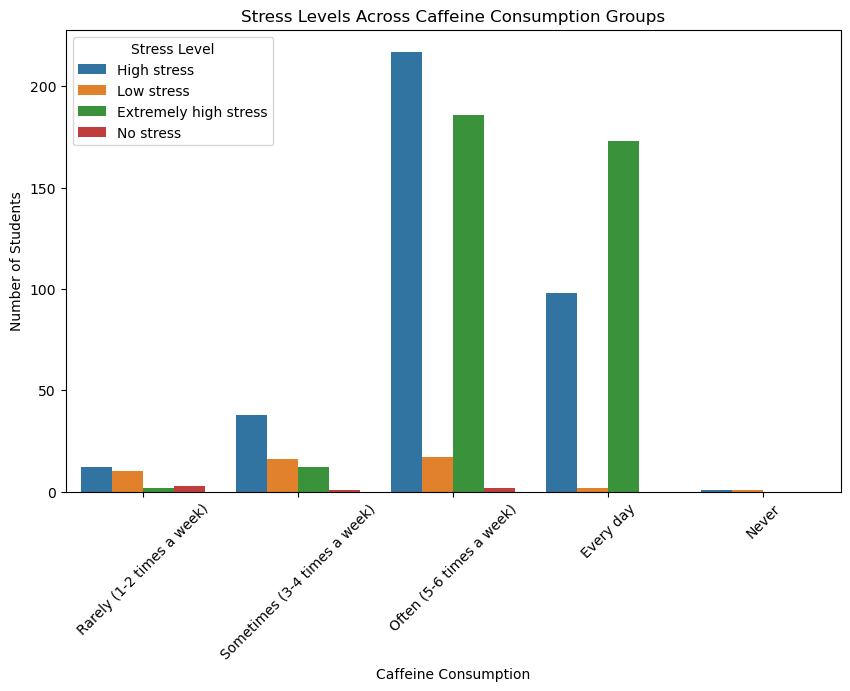

In [18]:
# make the plot bigger so the labels fit better
plt.figure(figsize=(10, 6))

# show how stress levels are distributed within each caffeine group
sns.countplot(data=students, x=caffeine_col, hue=stress_col)

# rotate labels so they are easier to read
plt.xticks(rotation=45)

# add title and axis labels
plt.title("Stress Levels Across Caffeine Consumption Groups")
plt.xlabel("Caffeine Consumption")
plt.ylabel("Number of Students")

# label the legend
plt.legend(title="Stress Level")

# show the graph
plt.show()

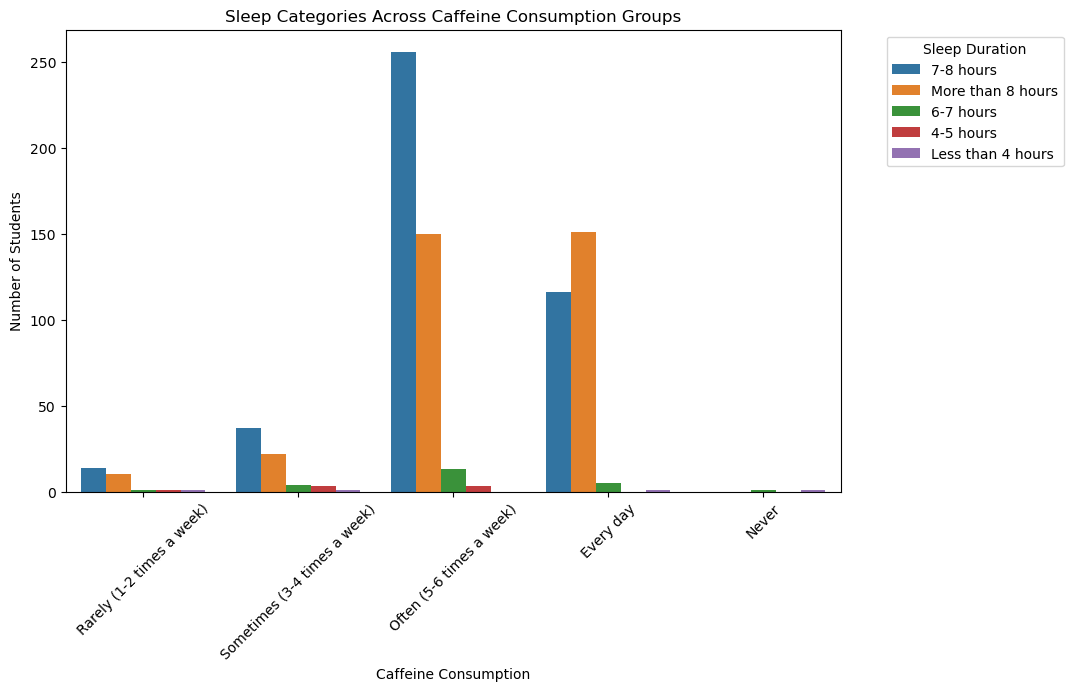

In [17]:
# make the plot bigger so the labels are easier to read
plt.figure(figsize=(10, 6))

# show how sleep categories are distributed within each caffeine group
sns.countplot(data=students, x=caffeine_col, hue=sleep_col)

# rotate labels so they fit better
plt.xticks(rotation=45)

# add title and axis labels
plt.title("Sleep Categories Across Caffeine Consumption Groups")
plt.xlabel("Caffeine Consumption")
plt.ylabel("Number of Students")

# move legend so it does not cover the graph
plt.legend(title="Sleep Duration", bbox_to_anchor=(1.05, 1), loc="upper left")

# show the graph
plt.show()

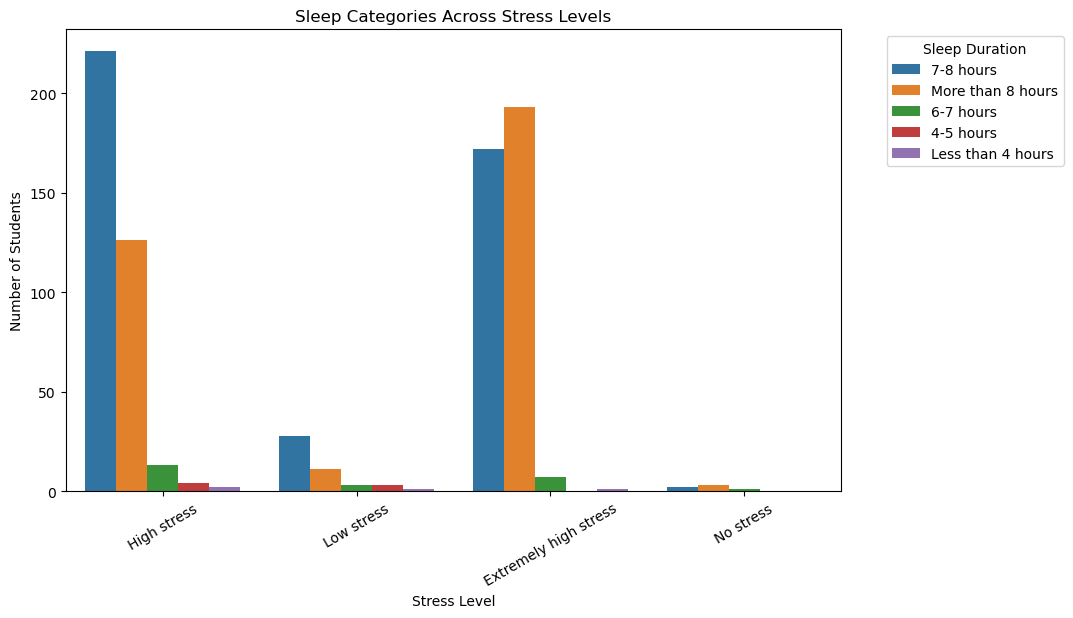

In [16]:
# make the plot bigger so it is easier to read
plt.figure(figsize=(10, 6))

# show how sleep categories are distributed within each stress group
sns.countplot(data=students, x=stress_col, hue=sleep_col)

# rotate labels so they fit better
plt.xticks(rotation=30)

# add title and axis labels
plt.title("Sleep Categories Across Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")

# move legend so it does not cover the graph
plt.legend(title="Sleep Duration", bbox_to_anchor=(1.05, 1), loc="upper left")

# show the graph
plt.show()

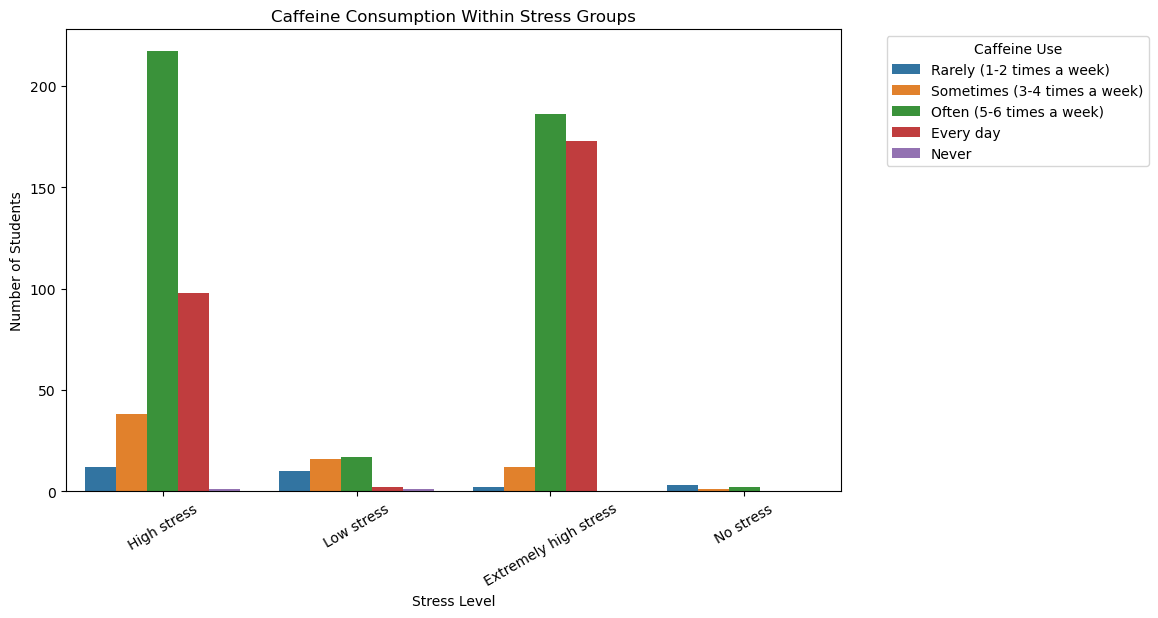

In [15]:
# Graph 5: compare caffeine use within each stress group

# make the plot bigger so everything is easier to read
plt.figure(figsize=(10, 6))

# show the number of students in each stress group, split by caffeine use
sns.countplot(data=students, x=stress_col, hue=caffeine_col)

# rotate labels so they fit better
plt.xticks(rotation=30)

# add title and axis labels
plt.title("Caffeine Consumption Within Stress Groups")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")

# move legend so it does not cover the graph
plt.legend(title="Caffeine Use", bbox_to_anchor=(1.05, 1), loc="upper left")

# show the graph
plt.show()